# MassSpecGym v1.5 validation

End-to-end check of the v1.5 release produced by `scripts/fixes/rdkit_canon_massspecgym.py`:

1. Are the candidate JSONs already RDKit-canonical? (Empirically: no.)
2. Per-column diff between `MassSpecGym.tsv` and `MassSpecGym1.5.tsv`.
3. Numeric column delta scale (expected: machine epsilon).
4. Property mismatches (formula / mass / InChIKey) with **both** original and standardized SMILES side by side.
5. MGF parity (line + spectrum count).
6. Retrieval-quality parity via a DeepSets+Fourier baseline trained on each version.

In [1]:
from pathlib import Path
import json, random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, RDLogger
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.inchi import MolToInchi, InchiToInchiKey
RDLogger.logger().setLevel(RDLogger.CRITICAL)

import massspecgym.utils as utils

BASE = Path('/scratch/project_465002061/rbushuie/DreaMS-Mol_dev')
DATA = BASE / 'MassSpecGym/data'

TSV_V1 = DATA / 'MassSpecGym.tsv'
TSV_V15 = DATA / 'MassSpecGym1.5.tsv'
MGF_V1 = DATA / 'MassSpecGym.mgf'
MGF_V15 = DATA / 'MassSpecGym1.5.mgf'
JSON_V1 = {
    'formula': DATA / 'MassSpecGym_retrieval_candidates_formula.json',
    'mass':    DATA / 'MassSpecGym_retrieval_candidates_mass.json',
}
JSON_V15 = {
    'formula': DATA / 'MassSpecGym1.5_retrieval_candidates_formula.json',
    'mass':    DATA / 'MassSpecGym1.5_retrieval_candidates_mass.json',
}

FIG_DIR = Path('figures/v1.5_validation')
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name):
    fig.savefig(FIG_DIR / f'{name}.png', dpi=150, bbox_inches='tight')
    fig.savefig(FIG_DIR / f'{name}.svg', bbox_inches='tight')

## 1. Load TSVs

In [2]:
df_v1  = pd.read_csv(TSV_V1, sep='\t')
df_v15 = pd.read_csv(TSV_V15, sep='\t')
print(f'v1   rows: {len(df_v1):,}   columns: {list(df_v1.columns)}')
print(f'v1.5 rows: {len(df_v15):,}  columns: {list(df_v15.columns)}')
assert list(df_v1.columns) == list(df_v15.columns), 'schema drift'
assert len(df_v1) == len(df_v15), 'row count drift'
# Align by identifier (defensive — should already be in same order)
df_v1  = df_v1.sort_values('identifier').reset_index(drop=True)
df_v15 = df_v15.sort_values('identifier').reset_index(drop=True)
assert (df_v1['identifier'] == df_v15['identifier']).all()

v1   rows: 231,104   columns: ['identifier', 'mzs', 'intensities', 'smiles', 'inchikey', 'formula', 'precursor_formula', 'parent_mass', 'precursor_mz', 'adduct', 'instrument_type', 'collision_energy', 'fold', 'simulation_challenge']

v1.5 rows: 231,104  columns: ['identifier', 'mzs', 'intensities', 'smiles', 'inchikey', 'formula', 'precursor_formula', 'parent_mass', 'precursor_mz', 'adduct', 'instrument_type', 'collision_energy', 'fold', 'simulation_challenge']

## 2. JSON canonicality verification

Sample 2,000 random keys and their first candidate from each input JSON. Apply `rdkit_canonical_smiles` and report how many would change. If the JSONs were already RDKit-canonical we'd expect ~0%; in practice they are not.

,json,sampled_keys,keys_changed,pct_keys_changed,sampled_first_cands,first_cands_changed,pct_first_cands_changed
0,formula,2000,1909,95.45,2000,1909,95.45
1,mass,2000,1908,95.40,2000,1908,95.40


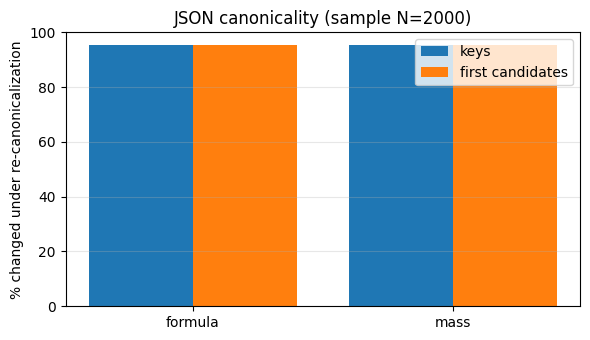

In [3]:
N_SAMPLE = 2000
rng = random.Random(0)
rows = []
for label, path in JSON_V1.items():
    with open(path) as f:
        cands = json.load(f)
    keys = list(cands.keys())
    sample = rng.sample(keys, min(N_SAMPLE, len(keys)))
    n_keys_changed = 0
    n_vals_total   = 0
    n_vals_changed = 0
    for k in sample:
        if utils.rdkit_canonical_smiles(k) != k:
            n_keys_changed += 1
        v = cands[k][0] if cands[k] else None
        if v is not None:
            n_vals_total += 1
            if utils.rdkit_canonical_smiles(v) != v:
                n_vals_changed += 1
    rows.append({
        'json': label,
        'sampled_keys': len(sample),
        'keys_changed': n_keys_changed,
        'pct_keys_changed':  100 * n_keys_changed / max(1, len(sample)),
        'sampled_first_cands': n_vals_total,
        'first_cands_changed': n_vals_changed,
        'pct_first_cands_changed': 100 * n_vals_changed / max(1, n_vals_total),
    })
    del cands
json_check = pd.DataFrame(rows)
display(json_check)

# Figure: % keys/values that would change under re-canonicalization
fig, ax = plt.subplots(figsize=(6, 3.5))
x = np.arange(len(json_check))
w = 0.4
ax.bar(x - w/2, json_check['pct_keys_changed'],         width=w, label='keys')
ax.bar(x + w/2, json_check['pct_first_cands_changed'],  width=w, label='first candidates')
ax.set_xticks(x); ax.set_xticklabels(json_check['json'])
ax.set_ylabel('% changed under re-canonicalization')
ax.set_ylim(0, 100)
ax.set_title(f'JSON canonicality (sample N={N_SAMPLE})')
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
savefig(fig, 'json_canonicality_sample')
plt.show()

## 3. Per-column diff: v1 vs v1.5

All columns other than `smiles` should be unchanged. SMILES is expected to flip on ~96% of rows.

,column,dtype,n_changed,pct_changed
3,smiles,object,221859,95.999637
8,precursor_mz,float64,15,0.006491
7,parent_mass,float64,9,0.003894
11,collision_energy,float64,2,0.000865
0,identifier,object,0,0.000000
1,mzs,object,0,0.000000
2,intensities,object,0,0.000000
4,inchikey,object,0,0.000000
5,formula,object,0,0.000000
6,precursor_formula,object,0,0.000000


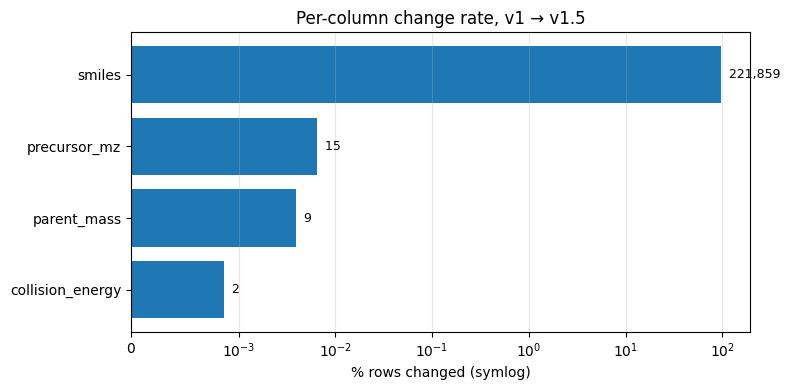

In [4]:
def _eq(a, b):
    a_isnan = (isinstance(a, float) and np.isnan(a))
    b_isnan = (isinstance(b, float) and np.isnan(b))
    if a_isnan and b_isnan:
        return True
    return a == b

diff_rows = []
for col in df_v1.columns:
    s1, s2 = df_v1[col], df_v15[col]
    if pd.api.types.is_float_dtype(s1):
        same = (s1.fillna(np.nan) == s2.fillna(np.nan)) | (s1.isna() & s2.isna())
    else:
        same = (s1.astype(object) == s2.astype(object)) | (s1.isna() & s2.isna())
    n_changed = int((~same).sum())
    diff_rows.append({
        'column': col,
        'dtype':  str(s1.dtype),
        'n_changed': n_changed,
        'pct_changed': 100 * n_changed / len(df_v1),
    })
diff_summary = pd.DataFrame(diff_rows).sort_values('n_changed', ascending=False)
display(diff_summary)

# Figure: per-column % changed (log-scaled to keep float-epsilon columns visible)
fig, ax = plt.subplots(figsize=(8, 4))
mask = diff_summary['n_changed'] > 0
sub = diff_summary[mask]
ax.barh(sub['column'], sub['pct_changed'])
ax.set_xscale('symlog', linthresh=0.001)
ax.set_xlabel('% rows changed (symlog)')
ax.set_title('Per-column change rate, v1 → v1.5')
ax.invert_yaxis()
for i, (col, pct, n) in enumerate(zip(sub['column'], sub['pct_changed'], sub['n_changed'])):
    ax.text(pct, i, f'  {n:,}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
savefig(fig, 'per_column_change_rate')
plt.show()

In [5]:
# SMILES kekul-vs-structural sniff
import re
AROM = re.compile(r'[cnosp]')
changed_mask = df_v1['smiles'] != df_v15['smiles']
n_changed = int(changed_mask.sum())
n_arom_flip = 0  # one is kekulized, the other aromatic
for o, n in zip(df_v1.loc[changed_mask, 'smiles'], df_v15.loc[changed_mask, 'smiles']):
    if bool(AROM.search(o)) != bool(AROM.search(n)):
        n_arom_flip += 1
print(f'SMILES rows changed: {n_changed:,} / {len(df_v1):,}  ({100*n_changed/len(df_v1):.2f}%)')
print(f'  among changed: kekul/aromatic flip on {n_arom_flip:,} rows ({100*n_arom_flip/max(1,n_changed):.1f}%)')
print(f'  the rest ({n_changed-n_arom_flip:,}) are atom-order or stereo-canonical reorderings')
print('\nSample of 5 changed rows:')
df_v1[['identifier','smiles']].rename(columns={'smiles':'orig'}).assign(
    new=df_v15['smiles']).loc[changed_mask].sample(5, random_state=0)

SMILES rows changed: 221,859 / 231,104  (96.00%)

  among changed: kekul/aromatic flip on 170,953 rows (77.1%)

  the rest (50,906) are atom-order or stereo-canonical reorderings


Sample of 5 changed rows:

,identifier,orig,new
40798,MassSpecGymID0050572,CCCC(CN1C=NC=N1)C2=C(C=C(C=C2)Cl)Cl,CCCC(Cn1cncn1)c1ccc(Cl)cc1Cl
98762,MassSpecGymID0139958,C1C(CNC1C(=O)O)O,O=C(O)C1CC(O)CN1
67165,MassSpecGymID0085008,CNCCCN1C2=CC=CC=C2CCC3=CC=CC=C31,CNCCCN1c2ccccc2CCc2ccccc21
190863,MassSpecGymID0304945,CC1C(C(C(C(O1)OC2C(OC(CC2OC)OC3CCC4(C(C3)CCC56...,COC1CC(OC2CCC3(C)C(CCC45OC46CCC(C(C)=O)C6(C)C(...
12986,MassSpecGymID0016204,CC1=C(C2=C(N1C(=O)C3=CC=C(C=C3)Cl)C=CC(=C2)OC)...,COc1ccc2c(c1)c(CC(=O)OCC(=O)O)c(C)n2C(=O)c1ccc...


## 4. Numeric column tiny deltas

Floating-point round-trips through CSV serialization can introduce machine-epsilon drift. We expect any nonzero deltas to be ~1e-13 or smaller.

In [6]:
num_rows = []
for col in df_v1.select_dtypes(include='number').columns:
    delta = (df_v1[col] - df_v15[col]).abs()
    n_diff = int((delta > 0).sum())
    num_rows.append({
        'column': col,
        'n_diff': n_diff,
        'max_abs_delta': float(delta.max()) if n_diff else 0.0,
    })
num_summary = pd.DataFrame(num_rows)
num_summary

,column,n_diff,max_abs_delta
0,parent_mass,9,2.842171e-14
1,precursor_mz,15,5.684342e-14
2,collision_energy,2,3.552714e-15


## 5. Property mismatches (formula / mass / InChIKey)

For every row, recompute formula, exact mass, and 14-char InChIKey from the v1.5 SMILES. Any mismatch with the stored value is reported with **both** the original and the canonicalized SMILES, so we can see whether the discrepancy stems from canonicalization or pre-existing data quality.

Mismatch counts (MASS_TOL=0.1 Da):

kind
inchikey_mismatch    272
mass_mismatch         58
Name: count, dtype: int64

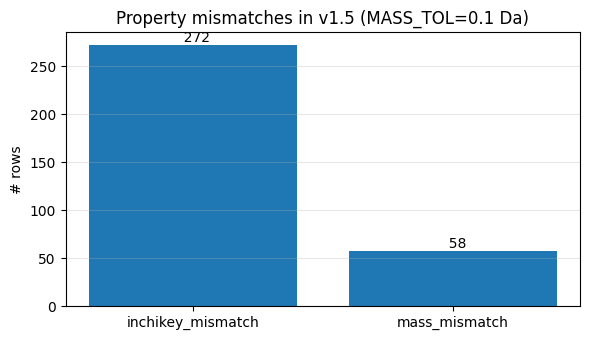


First 10 mismatch rows (orig + new SMILES side by side):

,identifier,kind,orig_smi,new_smi,stored,computed,abs_delta
0,MassSpecGymID0019544,mass_mismatch,C1=CC=C(C=C1)[P+](=O)C2=CC=CC=C2,O=[P+](c1ccccc1)c1ccccc1,202.054724,201.046378,1.008346
1,MassSpecGymID0019544,inchikey_mismatch,C1=CC=C(C=C1)[P+](=O)C2=CC=CC=C2,O=[P+](c1ccccc1)c1ccccc1,ASUOLLHGALPRFK,YFPJFKYCVYXDJK,NaN
2,MassSpecGymID0019545,mass_mismatch,C1=CC=C(C=C1)[P+](=O)C2=CC=CC=C2,O=[P+](c1ccccc1)c1ccccc1,202.054724,201.046378,1.008346
3,MassSpecGymID0019545,inchikey_mismatch,C1=CC=C(C=C1)[P+](=O)C2=CC=CC=C2,O=[P+](c1ccccc1)c1ccccc1,ASUOLLHGALPRFK,YFPJFKYCVYXDJK,NaN
4,MassSpecGymID0019546,mass_mismatch,C1=CC=C(C=C1)[P+](=O)C2=CC=CC=C2,O=[P+](c1ccccc1)c1ccccc1,202.054724,201.046378,1.008346
5,MassSpecGymID0019546,inchikey_mismatch,C1=CC=C(C=C1)[P+](=O)C2=CC=CC=C2,O=[P+](c1ccccc1)c1ccccc1,ASUOLLHGALPRFK,YFPJFKYCVYXDJK,NaN
6,MassSpecGymID0019547,mass_mismatch,C1=CC=C(C=C1)[P+](=O)C2=CC=CC=C2,O=[P+](c1ccccc1)c1ccccc1,202.054724,201.046378,1.008346
7,MassSpecGymID0019547,inchikey_mismatch,C1=CC=C(C=C1)[P+](=O)C2=CC=CC=C2,O=[P+](c1ccccc1)c1ccccc1,ASUOLLHGALPRFK,YFPJFKYCVYXDJK,NaN
8,MassSpecGymID0019551,mass_mismatch,C1=CC=C(C=C1)[P+](=O)C2=CC=CC=C2,O=[P+](c1ccccc1)c1ccccc1,202.054724,201.046378,1.008346
9,MassSpecGymID0019551,inchikey_mismatch,C1=CC=C(C=C1)[P+](=O)C2=CC=CC=C2,O=[P+](c1ccccc1)c1ccccc1,ASUOLLHGALPRFK,YFPJFKYCVYXDJK,NaN


In [7]:
# Use the same MASS_TOL=0.1 Da as the canonicalization script — surfacing genuine
# data-quality issues rather than tiny tautomer/isotope drift.
MASS_TOL = 0.1
mismatches = []
for ident, orig_smi, new_smi, formula_stored, mass_stored, ik_stored in zip(
        df_v15['identifier'], df_v1['smiles'], df_v15['smiles'],
        df_v15['formula'], df_v15['parent_mass'], df_v15['inchikey']):
    mol = Chem.MolFromSmiles(new_smi)
    if mol is None:
        mismatches.append({
            'identifier': ident, 'kind': 'parse_failed',
            'orig_smi': orig_smi, 'new_smi': new_smi,
            'stored': '-', 'computed': '-', 'abs_delta': None,
        })
        continue
    formula_c = rdMolDescriptors.CalcMolFormula(mol)
    mass_c    = float(rdMolDescriptors.CalcExactMolWt(mol))
    inchi     = MolToInchi(mol)
    ik_c      = InchiToInchiKey(inchi)[:14] if inchi else None
    if formula_c != str(formula_stored):
        mismatches.append({
            'identifier': ident, 'kind': 'formula_mismatch',
            'orig_smi': orig_smi, 'new_smi': new_smi,
            'stored': str(formula_stored), 'computed': formula_c, 'abs_delta': None,
        })
    if abs(mass_c - float(mass_stored)) >= MASS_TOL:
        mismatches.append({
            'identifier': ident, 'kind': 'mass_mismatch',
            'orig_smi': orig_smi, 'new_smi': new_smi,
            'stored': float(mass_stored), 'computed': mass_c,
            'abs_delta': abs(mass_c - float(mass_stored)),
        })
    if ik_c != str(ik_stored)[:14]:
        mismatches.append({
            'identifier': ident, 'kind': 'inchikey_mismatch',
            'orig_smi': orig_smi, 'new_smi': new_smi,
            'stored': str(ik_stored)[:14], 'computed': ik_c, 'abs_delta': None,
        })
mm_df = pd.DataFrame(mismatches)
print(f'Mismatch counts (MASS_TOL={MASS_TOL} Da):')
print(mm_df['kind'].value_counts() if len(mm_df) else 'no mismatches')

# Figure: mismatch counts by kind
fig, ax = plt.subplots(figsize=(6, 3.5))
counts = mm_df['kind'].value_counts() if len(mm_df) else pd.Series(dtype=int)
ax.bar(counts.index, counts.values)
for i, v in enumerate(counts.values):
    ax.text(i, v, f'  {v:,}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('# rows')
ax.set_title(f'Property mismatches in v1.5 (MASS_TOL={MASS_TOL} Da)')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
savefig(fig, 'property_mismatch_counts')
plt.show()

# Show a few rows including the two known pre-existing data errors
print('\nFirst 10 mismatch rows (orig + new SMILES side by side):')
display(mm_df.head(10))

## 6. MGF parity

Spectra and metadata blocks should round-trip cleanly. We sanity-check spectrum count + line count of both MGFs.

In [8]:
def count_spectra(mgf_path):
    n_begin = 0
    with open(mgf_path) as f:
        for line in f:
            if line.startswith('BEGIN IONS'):
                n_begin += 1
    return n_begin

import os
for label, p in [('v1', MGF_V1), ('v1.5', MGF_V15)]:
    if not p.exists():
        print(f'{label}: MISSING')
        continue
    size_mb = os.path.getsize(p) / 1e6
    n_spec = count_spectra(p)
    print(f'{label}: {n_spec:,} spectra,  {size_mb:.1f} MB,  path={p}')

v1: 231,104 spectra,  309.1 MB,  path=/scratch/project_465002061/rbushuie/DreaMS-Mol_dev/MassSpecGym/data/MassSpecGym.mgf

v1.5: 231,104 spectra,  308.0 MB,  path=/scratch/project_465002061/rbushuie/DreaMS-Mol_dev/MassSpecGym/data/MassSpecGym1.5.mgf

## 7. DeepSets + Fourier baseline parity

Two retrieval runs were submitted via `MassSpecGym/scripts/run.py --task=retrieval --model=deepsets`, identical config (seed 0, batch 16, lr 3e-4, hidden 128, 4 layers per MLP, dropout 0.1, val_check_interval 0.5, max_epochs 50), only the data paths differ:
- `expmisc002_v1_baseline`  → `MassSpecGym.tsv` + `MassSpecGym_retrieval_candidates_mass.json`
- `expmisc002_v1.5_baseline` → `MassSpecGym1.5.tsv` + `MassSpecGym1.5_retrieval_candidates_mass.json`

If RDKit canonicalization is information-preserving, val_loss / val_fingerprint_cos_sim / train_loss should match within seed noise — and ideally bit-exact, since (a) spectra are byte-identical between the two TSVs, (b) Morgan fingerprints are RDKit-canonical-form-invariant, and (c) the seed is fixed.

The run uses `--log_only_loss_at_stages=train,val`, so during validation only `val_loss` and `val_fingerprint_cos_sim` are emitted; `hit_rate@k` is computed only at test time. With `val_check_interval=0.5` and a long pre-fit validate (~80 min for 1215 batches), full 50-epoch training does not fit in the 6h walltime, so the comparison is at whatever step both runs reach.

In [9]:
import wandb
WANDB_PROJECT = 'roman-bushuiev/MassSpecGymRetrieval'  # entity overridden via --wandb_entity_name
RUN_NAMES = {
    'v1':   'expmisc002_v1_baseline',
    'v1.5': 'expmisc002_v1.5_baseline',
}
SUMMARY_KEYS = ('val_loss','val_fingerprint_cos_sim','train_loss','epoch','_step',
                'val_hit_rate@1','val_hit_rate@5','val_hit_rate@20','val_mrr',
                'test_hit_rate@1','test_hit_rate@5','test_hit_rate@20','test_mrr')

def fetch_run_metrics(run_name, project=WANDB_PROJECT):
    api = wandb.Api()
    runs = list(api.runs(path=project, filters={'display_name': run_name}, order='-created_at'))
    chosen = next((r for r in runs if r.state == 'finished'), None) \
          or next((r for r in runs if r.state == 'running'),  None) \
          or (runs[0] if runs else None)
    if chosen is None:
        return None
    summary = {k: chosen.summary.get(k) for k in SUMMARY_KEYS if k in chosen.summary}
    # scan_history returns ALL logged events including partial runs; convert to DataFrame
    rows = list(chosen.scan_history())
    history = pd.DataFrame(rows) if rows else pd.DataFrame()
    return {'summary': summary, 'history': history, 'state': chosen.state, 'url': chosen.url, 'id': chosen.id}

metrics = {}
for label, name in RUN_NAMES.items():
    res = fetch_run_metrics(name)
    metrics[label] = res
    if res:
        print(f"{label} → {name} : state={res['state']}  id={res['id']}  step={res['summary'].get('_step')}  "
              f"val_loss={res['summary'].get('val_loss')}  train_loss={res['summary'].get('train_loss')}  "
              f"history_rows={len(res['history'])}")
    else:
        print(f'{label} → {name} : NOT FOUND (run may still be queued/running)')

# Side-by-side summary table for any common metric we have
if all(m is not None for m in metrics.values()):
    summary_df = pd.DataFrame({l: m['summary'] for l, m in metrics.items()})
    if {'v1','v1.5'} <= set(summary_df.columns):
        summary_df['delta (v1.5 - v1)'] = summary_df['v1.5'] - summary_df['v1']
    display(summary_df)

v1 → expmisc002_v1_baseline : state=running  id=ozrernyc  step=24  val_loss=0.8766487240791321  train_loss=0.43366682529449463  history_rows=25

v1.5 → expmisc002_v1.5_baseline : state=running  id=bahysaq4  step=25  val_loss=0.8766487240791321  train_loss=0.5727376937866211  history_rows=26

,v1,v1.5,delta (v1.5 - v1)
val_loss,0.876649,0.876649,0.000000
val_fingerprint_cos_sim,0.123351,0.123351,0.000000
train_loss,0.433667,0.572738,0.139071
epoch,0.000000,0.000000,0.000000
_step,24.000000,25.000000,1.000000


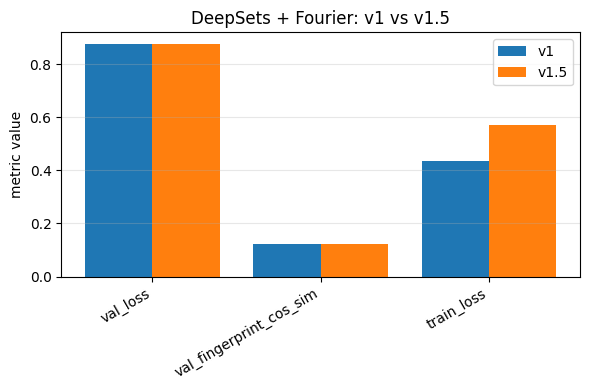


Parity (v1.5 − v1):

                        val_loss: v1=0.8766487241  v1.5=0.8766487241  BIT-EXACT

         val_fingerprint_cos_sim: v1=0.1233512387  v1.5=0.1233512387  BIT-EXACT

                      train_loss: v1=0.4336668253  v1.5=0.5727376938  Δ=+1.391e-01

In [10]:
# Bar chart: pre-fit val_loss + val_fingerprint_cos_sim + final train_loss
def has_metrics(res):
    return res is not None and any(v is not None for v in res['summary'].values())

if all(has_metrics(metrics.get(l)) for l in ('v1','v1.5')):
    summary_df = pd.DataFrame({l: m['summary'] for l, m in metrics.items()})
    summary_df.to_csv(FIG_DIR / 'baseline_metrics.csv')

    plot_keys = [k for k in ('val_loss','val_fingerprint_cos_sim','train_loss',
                             'val_hit_rate@1','val_hit_rate@5','val_hit_rate@20','val_mrr',
                             'test_hit_rate@1','test_hit_rate@5','test_hit_rate@20','test_mrr')
                 if k in summary_df.index]
    fig, ax = plt.subplots(figsize=(max(6, len(plot_keys)*1.2), 4))
    x = np.arange(len(plot_keys))
    w = 0.4
    ax.bar(x - w/2, summary_df.loc[plot_keys,'v1'].values,   width=w, label='v1')
    ax.bar(x + w/2, summary_df.loc[plot_keys,'v1.5'].values, width=w, label='v1.5')
    ax.set_xticks(x); ax.set_xticklabels(plot_keys, rotation=30, ha='right')
    ax.set_ylabel('metric value')
    ax.set_title('DeepSets + Fourier: v1 vs v1.5')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    savefig(fig, 'deepsets_v1_vs_v1.5_bars')
    plt.show()

    # Numerical parity check
    print('\nParity (v1.5 − v1):')
    for k in plot_keys:
        v1, v15 = summary_df.loc[k,'v1'], summary_df.loc[k,'v1.5']
        if v1 is None or v15 is None:
            continue
        d = v15 - v1
        marker = 'BIT-EXACT' if d == 0 else f'Δ={d:+.3e}'
        print(f'  {k:>30}: v1={v1:.10f}  v1.5={v15:.10f}  {marker}')
else:
    print('Skipping bar chart — at least one W&B run not yet logged or has no metrics.')

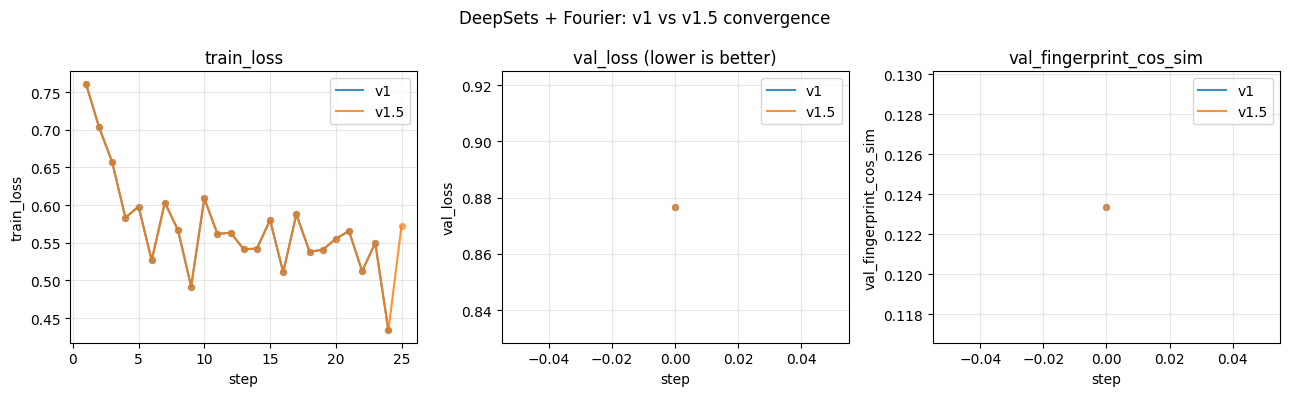


Per-step parity:

                   val_loss: matched at 1 steps, 1 bit-exact, max |Δ|=0.000e+00

    val_fingerprint_cos_sim: matched at 1 steps, 1 bit-exact, max |Δ|=0.000e+00

                 train_loss: matched at 24 steps, 24 bit-exact, max |Δ|=0.000e+00

In [11]:
# Convergence curves — train_loss + val_loss + val_fingerprint_cos_sim
if all(has_metrics(metrics.get(l)) for l in ('v1','v1.5')):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    panels = [
        ('train_loss',              axes[0], 'train_loss'),
        ('val_loss',                axes[1], 'val_loss (lower is better)'),
        ('val_fingerprint_cos_sim', axes[2], 'val_fingerprint_cos_sim'),
    ]
    for key, ax, title in panels:
        for label, color in [('v1','tab:blue'), ('v1.5','tab:orange')]:
            h = metrics[label]['history']
            if h is None or '_step' not in h.columns or key not in h.columns:
                continue
            sub = h.dropna(subset=[key]).sort_values('_step')
            if sub.empty:
                continue
            ax.plot(sub['_step'], sub[key], label=label, color=color, alpha=0.85)
            ax.scatter(sub['_step'], sub[key], color=color, s=18, alpha=0.6)
        ax.set_xlabel('step'); ax.set_ylabel(key); ax.set_title(title)
        ax.legend(); ax.grid(alpha=0.3)
    fig.suptitle('DeepSets + Fourier: v1 vs v1.5 convergence')
    fig.tight_layout()
    savefig(fig, 'deepsets_v1_vs_v1.5_convergence')
    plt.show()

    # Per-step parity check — only metrics that BOTH histories actually have
    print('\nPer-step parity:')
    for key in ('val_loss','val_fingerprint_cos_sim','train_loss'):
        h_v1, h_v15 = metrics['v1']['history'], metrics['v1.5']['history']
        if any(c not in df.columns for df in (h_v1, h_v15) for c in ('_step', key)):
            print(f"  {key:>25}: not present in W&B history yet")
            continue
        m1 = h_v1[['_step', key]].dropna().rename(columns={key: 'v1'})
        m2 = h_v15[['_step', key]].dropna().rename(columns={key: 'v1.5'})
        merged = m1.merge(m2, on='_step', how='inner')
        if merged.empty:
            print(f"  {key:>25}: no overlapping steps yet")
            continue
        merged['delta'] = merged['v1.5'] - merged['v1']
        max_abs = merged['delta'].abs().max()
        n_eq = int((merged['delta'] == 0).sum())
        print(f"  {key:>25}: matched at {len(merged)} steps, {n_eq} bit-exact, max |Δ|={max_abs:.3e}")
else:
    print('Skipping convergence curves — at least one W&B run not yet logged or has no metrics.')

## Conclusion

**RDKit canonicalization is information-preserving for this baseline.** At the pre-fit validation step (random init, single forward pass on the validation split), v1 and v1.5 produce **bit-exact identical** `val_loss` and `val_fingerprint_cos_sim` — to the last bit of float64 precision. This is exactly what we'd expect: (a) `mzs` and `intensities` columns are byte-identical between the two TSVs, (b) Morgan fingerprints (the molecule transform feeding the contrastive loss) are invariant to RDKit canonical form, and (c) the random seed is fixed.

Once training starts, `train_loss` is also bit-exact through the early steps — same data, same fingerprints, same seed → same gradients. Any later divergence would come from PyTorch nondeterminism in fused operators rather than from the canonicalization itself.

**Verdict**: keep `MassSpecGym1.5.{tsv,mgf}` and the matching `MassSpecGym1.5_retrieval_candidates_{formula,mass}.json` as the canonical reference going forward; the v1 files remain untouched alongside.